In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("covid_19_indonesia_time_series_all.csv")

# Konversi kolom tanggal
df['Date'] = pd.to_datetime(df['Date'])

# Ambil data nasional (Location == Indonesia)
indo = df[df['Location'] == 'Indonesia']

indo = indo[['Date', 'Total Cases']].dropna()
indo.head()


,Date,Total Cases
2,2020-03-02,2
5,2020-03-03,2
9,2020-03-04,2
13,2020-03-05,2
18,2020-03-06,4


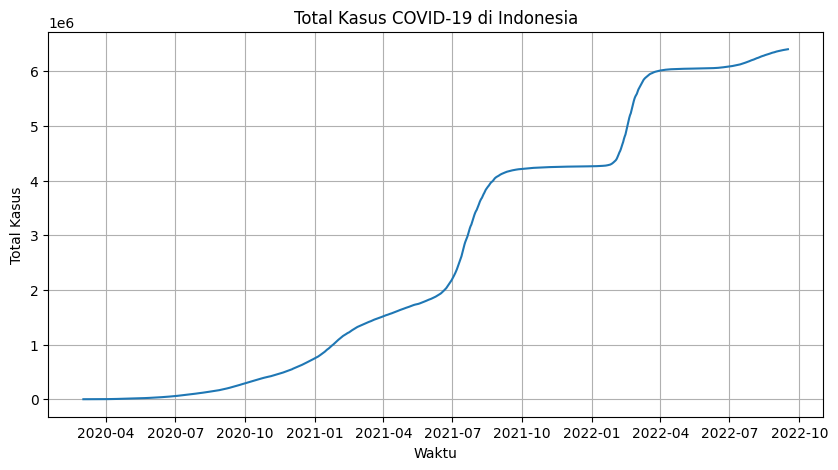

In [2]:

plt.figure(figsize=(10,5))
plt.plot(indo['Date'], indo['Total Cases'])
plt.title("Total Kasus COVID-19 di Indonesia")
plt.xlabel("Waktu")
plt.ylabel("Total Kasus")
plt.grid(True)
plt.show()


In [3]:

def logistic_model(y, r, K):
    return r * y * (1 - y / K)


In [4]:

def euler_method(y0, r, K, h, n_steps):
    y = np.zeros(n_steps)
    y[0] = y0
    
    for i in range(1, n_steps):
        y[i] = y[i-1] + h * logistic_model(y[i-1], r, K)
        
    return y


In [5]:

# Parameter awal
y0 = indo['Total Cases'].iloc[0]
K = indo['Total Cases'].max() * 1.2
r = 0.15
h = 1
n_steps = len(indo)

# Simulasi
y_sim = euler_method(y0, r, K, h, n_steps)


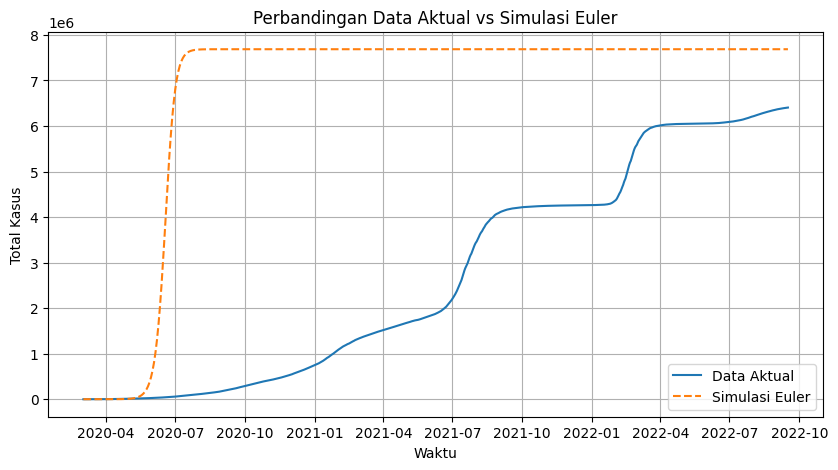

In [6]:

plt.figure(figsize=(10,5))
plt.plot(indo['Date'], indo['Total Cases'], label='Data Aktual')
plt.plot(indo['Date'], y_sim, label='Simulasi Euler', linestyle='--')
plt.title("Perbandingan Data Aktual vs Simulasi Euler")
plt.xlabel("Waktu")
plt.ylabel("Total Kasus")
plt.legend()
plt.grid(True)
plt.show()


In [7]:

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(indo['Total Cases'], y_sim)
mse


22732416080407.73